In [3]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load Excel dataset
data = pd.read_excel("iris (1).xlsx")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Convert labels to numbers
le = LabelEncoder()
y = le.fit_transform(y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear kernel
linear_model = svm.SVC(kernel='linear')
linear_model.fit(X_train, y_train)

pred_linear = linear_model.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, pred_linear))
print("Confusion Matrix (Linear):")
print(confusion_matrix(y_test, pred_linear))


# RBF kernel
rbf_model = svm.SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

pred_rbf = rbf_model.predict(X_test)

print("RBF Kernel Accuracy:", accuracy_score(y_test, pred_rbf))
print("Confusion Matrix (RBF):")
print(confusion_matrix(y_test, pred_rbf))

Linear Kernel Accuracy: 1.0
Confusion Matrix (Linear):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
RBF Kernel Accuracy: 1.0
Confusion Matrix (RBF):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Accuracy Score: 0.9305
Confusion Matrix:
[[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0   0   0   0   0   0   0
    0   0   0

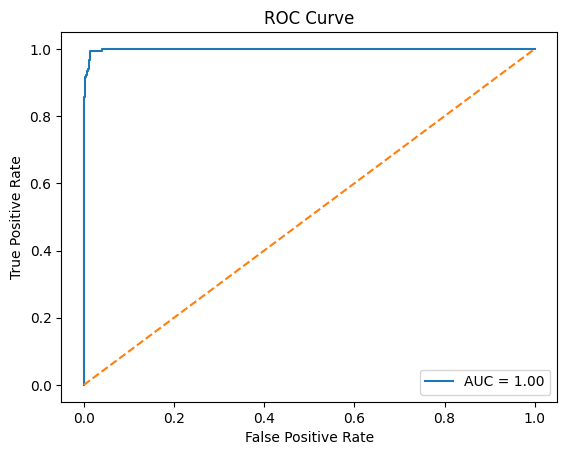

AUC Score: 0.9986510157307876


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

# Load dataset
data = pd.read_excel("letter-recognition.xlsx")

# Features and target
X = data.iloc[:,1:]
y = data.iloc[:,0]

# Convert letters to numbers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Build SVM classifier
model = svm.SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# ROC Curve (one vs rest example for class 1)
y_test_bin = label_binarize(y_test, classes=range(26))
y_score = model.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin[:,1], y_score[:,1])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [6]:
# -*- coding: utf-8 -*-
"""Lab-6-SVM.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Az59g2DkfeHUafr25_b2GR321r7kn0kN
"""

import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

digits.target

dir(digits)

digits.target_names

df = pd.DataFrame(digits.data,digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.3)

"""Using RBF kernel"""

from sklearn.svm import SVC
rbf_model = SVC(kernel='rbf')

len(X_train)

len(X_test)

rbf_model.fit(X_train, y_train)

rbf_model.score(X_test,y_test)

"""Using Linear kernel"""

linear_model = SVC(kernel='linear')
linear_model.fit(X_train,y_train)

linear_model.score(X_test,y_test)

0.9703703703703703